In [4]:
%load_ext autoreload
%autoreload 2
import tensorflow as tf
import numpy as np
import os
import logging
import string
import random
import yaml
from datetime import datetime
from tqdm.notebook import tqdm

from dimenet.model.dimenet import DimeNet
from dimenet.model.dimenet_pp import DimeNetPP
from dimenet.model.activations import swish
from dimenet.training.trainer import Trainer
from dimenet.training.metrics import Metrics
"""from dimenet.training.data_container import DataContainer
from dimenet.training.data_provider import DataProvider"""
from custom.data_container import DataContainer
from custom.data_provider import DataProvider


2026-06-15 08:57:23.132202: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critical operations:  AVX2 AVX_VNNI FMA
To enable them in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-06-15 08:57:23.396728: I tensorflow/core/util/util.cc:169] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-15 08:57:23.471986: E tensorflow/stream_executor/cuda/cuda_blas.cc:2981] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-15 08:57:24.396028: W tensorflow/stream_executor/platform/default/dso_loader.cc:64] Could not load dynamic library 'libnvinfer.so.7'; dlerror: li

In [5]:
# Set up logger
logger = logging.getLogger()
logger.handlers = []
ch = logging.StreamHandler()
formatter = logging.Formatter(
        fmt='%(asctime)s (%(levelname)s): %(message)s',
        datefmt='%Y-%m-%d %H:%M:%S')
ch.setFormatter(formatter)
logger.addHandler(ch)
logger.setLevel('INFO')

os.environ['TF_CPP_MIN_LOG_LEVEL'] = '1'
tf.get_logger().setLevel('WARN')
tf.autograph.set_verbosity(2)

In [6]:
# Params:
config_file = "config_pp.yaml"
directory = "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/20260614_155420_G4MIDSLh_ppvPHYv1"  # Fill this in

### Load config

In [7]:
# config.yaml for DimeNet, config_pp.yaml for DimeNet++
with open(config_file, 'r') as c:
    config = yaml.safe_load(c)

In [8]:
model_name = config['model_name']

if model_name == "dimenet":
    num_bilinear = config['num_bilinear']
elif model_name == "dimenet++":
    out_emb_size = config['out_emb_size']
    int_emb_size = config['int_emb_size']
    basis_emb_size = config['basis_emb_size']
    extensive = config['extensive']
else:
    raise ValueError(f"Unknown model name: '{model_name}'")
    
emb_size = config['emb_size']
num_blocks = config['num_blocks']

num_spherical = config['num_spherical']
num_radial = config['num_radial']
output_init = config['output_init']

cutoff = config['cutoff']
envelope_exponent = config['envelope_exponent']

num_before_skip = config['num_before_skip']
num_after_skip = config['num_after_skip']
num_dense_output = config['num_dense_output']

num_train = config['num_train']
#num_valid = config['num_valid']
data_seed = config['data_seed']
#dataset = config['dataset']
logdir = config['logdir']

num_steps = config['num_steps']
ema_decay = config['ema_decay']

learning_rate = config['learning_rate']
warmup_steps = config['warmup_steps']
decay_rate = config['decay_rate']
decay_steps = config['decay_steps']

batch_size = config['batch_size']
evaluation_interval = config['evaluation_interval']
save_interval = config['save_interval']
restart = config['restart']
comment = config['comment']
#targets = config['targets']

### Load dataset

In [9]:
data_root = "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/upload data_modia-phyml-26"


data_container = DataContainer(data_root, cutoff, train=False)

# Initialize DataProvider (splits dataset into 3 sets based on data_seed and provides tf.datasets)
data_provider = DataProvider(data_container, num_train, train=False, batch_size=batch_size,
                             seed=data_seed, randomized=True)

# Initialize datasets
dataset = data_provider.get_dataset('test').prefetch(tf.data.experimental.AUTOTUNE)
dataset_iter = iter(dataset)

2026-06-15 08:57:26.322872: E tensorflow/stream_executor/cuda/cuda_driver.cc:265] failed call to cuInit: CUDA_ERROR_UNKNOWN: unknown error
2026-06-15 08:57:26.322922: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:169] retrieving CUDA diagnostic information for host: n7student
2026-06-15 08:57:26.322929: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:176] hostname: n7student
2026-06-15 08:57:26.323075: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:200] libcuda reported version is: 570.211.1
2026-06-15 08:57:26.323100: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:204] kernel reported version is: 570.211.1
2026-06-15 08:57:26.323105: I tensorflow/stream_executor/cuda/cuda_diagnostics.cc:310] kernel version seems to match DSO: 570.211.1
2026-06-15 08:57:26.332849: I tensorflow/core/platform/cpu_feature_guard.cc:193] This TensorFlow binary is optimized with oneAPI Deep Neural Network Library (oneDNN) to use the following CPU instructions in performance-critic

### Initialize model

In [10]:
if model_name == "dimenet":
    model = DimeNet(
            emb_size=emb_size, num_blocks=num_blocks, num_bilinear=num_bilinear,
            num_spherical=num_spherical, num_radial=num_radial,
            cutoff=cutoff, envelope_exponent=envelope_exponent,
            num_before_skip=num_before_skip, num_after_skip=num_after_skip,
            num_dense_output=num_dense_output, num_targets=1,
            activation=swish, output_init=output_init)
elif model_name == "dimenet++":
    model = DimeNetPP(
            emb_size=emb_size, out_emb_size=out_emb_size,
            int_emb_size=int_emb_size, basis_emb_size=basis_emb_size,
            num_blocks=num_blocks, num_spherical=num_spherical, num_radial=num_radial,
            cutoff=cutoff, envelope_exponent=envelope_exponent,
            num_before_skip=num_before_skip, num_after_skip=num_after_skip,
            num_dense_output=num_dense_output, num_targets=1,
            activation=swish, extensive=extensive, output_init=output_init)
else:
    raise ValueError(f"Unknown model name: '{model_name}'")

### Initialize trainer

In [11]:
trainer = Trainer(model, learning_rate, warmup_steps,
                  decay_steps, decay_rate,
                  ema_decay=ema_decay, max_grad_norm=1000)

### Load weights from model at best step

In [12]:
#####################################################################
# Load the trained model from your own training run

best_ckpt_file = os.path.join(directory, 'best', 'ckpt')
#####################################################################
# Uncomment this if you want to use a pretrained model
#directory = f"pretrained/dimenet_pp/{targets[0]}"
#best_ckpt_file = os.path.join(directory, 'ckpt')
#####################################################################

model.load_weights(best_ckpt_file)

### Prediction loop

In [13]:
# Initialize aggregates
metrics = Metrics('val', ["energy"])
preds_total = np.zeros([data_provider.nsamples['test'], 1], dtype=np.float32)
ids_total = np.zeros([data_provider.nsamples['test']], dtype=np.int32)

In [14]:
steps_per_epoch = int(np.ceil(data_provider.nsamples['test'] / batch_size))

for step in tqdm(range(steps_per_epoch)):
    preds, ids = trainer.predict_on_batch(dataset_iter, metrics)
    
    # Update predictions
    batch_start = step * batch_size
    batch_end = min((step + 1) * batch_size, data_provider.nsamples['test'])
    preds_total[batch_start:batch_end] = preds.numpy()
    ids_total[batch_start:batch_end] = ids.numpy()

  0%|          | 0/52 [00:00<?, ?it/s]

InvalidArgumentError: Graph execution error:

Detected at node 'dimenet/embedding/dense_1/BiasAdd' defined at (most recent call last):
    File "/usr/lib/python3.10/runpy.py", line 196, in _run_module_as_main
      return _run_code(code, main_globals, None,
    File "/usr/lib/python3.10/runpy.py", line 86, in _run_code
      exec(code, run_globals)
    File "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/.venv/lib/python3.10/site-packages/ipykernel_launcher.py", line 18, in <module>
      app.launch_new_instance()
    File "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/.venv/lib/python3.10/site-packages/traitlets/config/application.py", line 1082, in launch_instance
      app.start()
    File "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/.venv/lib/python3.10/site-packages/ipykernel/kernelapp.py", line 758, in start
      self.io_loop.start()
    File "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/.venv/lib/

In [15]:
print(f"MAE: {metrics.mean_mae}")
print(f"logMAE: {metrics.mean_log_mae}")

MAE: 0.0
logMAE: -inf


/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/dimenet/dimenet/training/metrics.py:68: RuntimeWarning: divide by zero encountered in log
  return np.mean(np.log(self.maes)).item()


In [ ]:
preds_total = preds_total[:, 0]

In [ ]:
print(preds_total.shape)
ids_total.shape

(826,)


(826,)

In [ ]:
import pandas as pd

submission_df = pd.DataFrame({
    "id": ids_total,
    "energy": preds_total,
})


submission_path = f"../submission/submission_dimenet_{comment}.csv"
submission_df.to_csv(submission_path, index=False)

display(submission_df.head())
print("Fichier créé:", submission_path)

assert list(submission_df.columns) == ["id", "energy"]
assert len(submission_df) == len(data_container.id)
assert not submission_df["energy"].isna().any()

,id,energy
0,3948,-47.337757
1,3839,-63.761059
2,3929,-68.015694
3,3936,-75.928871
4,3984,-72.822174


Fichier créé: ./submission_dimenet_ppvPHYv1.csv


# Target scaling

In [59]:
data_root = "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/upload data_modia-phyml-26"


data_container = DataContainer(data_root, cutoff, train=True)

# Initialize DataProvider (splits dataset into 3 sets based on data_seed and provides tf.datasets)
data_provider = DataProvider(data_container, num_train, train=True, batch_size=batch_size,
                             seed=data_seed, randomized=True)

# Initialize datasets
train = {}
validation = {}
train['dataset'] = data_provider.get_dataset('train').prefetch(tf.data.experimental.AUTOTUNE)
train['dataset_iter'] = iter(train['dataset'])
validation['dataset'] = data_provider.get_dataset('val').prefetch(tf.data.experimental.AUTOTUNE)
validation['dataset_iter'] = iter(validation['dataset'])

(50408,)


In [ ]:
Z_TO_ID = {
    1:0,  2:1, 6:2, 7:3, 8:4, 11:5, 16:6, 17:7
}

def get_feats(dataset, dataset_name):
    n_sample = data_provider.nsamples[dataset_name]
    n_batches = int(np.ceil(n_sample / batch_size))

    all_ids = []
    all_true = np.zeros(n_sample)
    all_atoms = np.zeros((n_sample, len(Z_TO_ID)))

    for b in range(n_batches):

        inputs, targets = next(dataset['dataset_iter'])
        all_true[b * batch_size : b * batch_size + len(targets)] = targets.numpy().squeeze()

        # atom types for each molecule
        Z = inputs["Z"].numpy()
        N = inputs["N"].numpy()
        all_ids.extend(inputs["id"].numpy())

        print(inputs["id"][0])
        print(Z[:N[2]])
        start = 0
        for e, n in enumerate(N):
            for z in Z[start:start+n]:
                all_atoms[b*batch_size + e, Z_TO_ID[z]] += 1
            start += n
        print(all_atoms[b*batch_size])
        1/0
    return all_true, all_atoms, all_ids

all_true_train, all_atoms_train, ids_train = get_feats(train, "train")
all_true_val, all_atoms_val, ids_test = get_feats(validation, "val")

tf.Tensor(2224, shape=(), dtype=int32)
[8 6 6 8 6 6 1 1 1 1 1 1 1 1 1 1]
[10.  0.  4.  0.  2.  0.  0.  0.]


ZeroDivisionError: division by zero

In [53]:
all_true_train.shape

(2310,)

In [54]:
all_atoms_train.shape

(2310, 8)

In [55]:
all_atoms_train[23, :]

array([8., 0., 5., 0., 1., 0., 0., 0.])

In [51]:
ids_train[23]

1757

In [56]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
lr.fit(all_atoms_train, all_true_train)
print(lr.score(all_atoms_train, all_true_train))
lr.score(all_atoms_val, all_true_val)

0.9972623006971896


0.9965944277541193

# Validation

In [ ]:
data_root = "/home/n7student/Documents/2A/S2/contraintes/projet_kaggle/upload data_modia-phyml-26"


data_container = DataContainer(data_root, cutoff, train=True)

# Initialize DataProvider (splits dataset into 3 sets based on data_seed and provides tf.datasets)
data_provider = DataProvider(data_container, num_train, train=True, batch_size=batch_size,
                             seed=data_seed, randomized=True)

# Initialize datasets
validation = {}
train = {}
#train['dataset'] = data_provider.get_dataset('train').prefetch(tf.data.experimental.AUTOTUNE)
#train['dataset_iter'] = iter(train['dataset'])
validation['dataset'] = data_provider.get_dataset('val').prefetch(tf.data.experimental.AUTOTUNE)
validation['dataset_iter'] = iter(validation['dataset'])

In [ ]:
all_ids = []
all_true = []
all_pred = []
all_sizes = []
all_atoms = []

In [ ]:
n_val = data_provider.nsamples['val']
n_batches = int(np.ceil(n_val / batch_size))

for _ in range(n_batches):

    inputs, targets = next(validation['dataset_iter'])

    preds = model(inputs, training=False)

    # molecule-level information
    all_ids.extend(inputs["id"].numpy())
    all_sizes.extend(inputs["N"].numpy())

    all_true.extend(targets.numpy().squeeze())
    all_pred.extend(preds.numpy().squeeze())

    # atom types for each molecule
    Z = inputs["Z"].numpy()
    N = inputs["N"].numpy()

    start = 0
    for n in N:
        all_atoms.append(set(Z[start:start+n]))
        start += n

In [ ]:
all_ids = np.array(all_ids)
all_true = np.array(all_true)
all_pred = np.array(all_pred)
all_sizes = np.array(all_sizes)

errors = np.abs(all_true - all_pred)

In [ ]:
np.mean(errors)

0.033979606

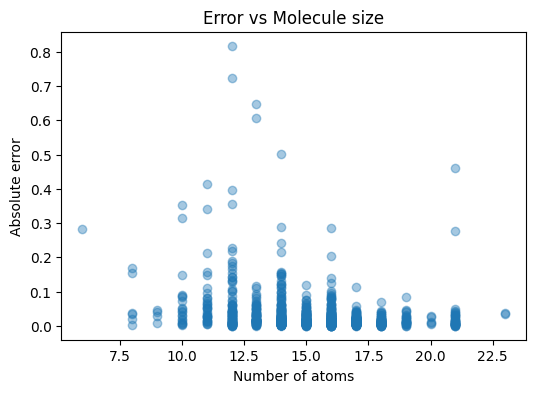

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(all_sizes, errors, alpha=0.4)
plt.xlabel("Number of atoms")
plt.ylabel("Absolute error")
plt.title("Error vs Molecule size")
plt.show()

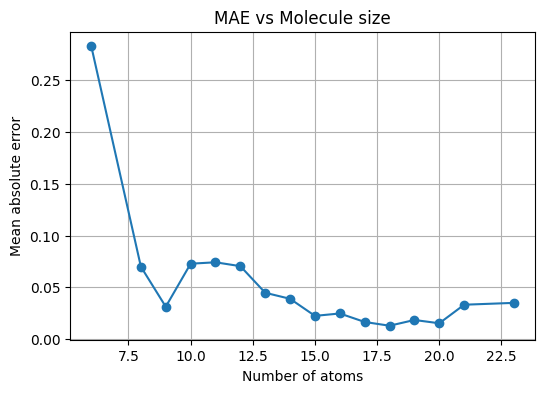

In [ ]:
sizes = np.unique(all_sizes)

mean_err = [
    errors[all_sizes == s].mean()
    for s in sizes
]

plt.figure(figsize=(6,4))
plt.plot(sizes, mean_err, marker='o')
plt.xlabel("Number of atoms")
plt.ylabel("Mean absolute error")
plt.title("MAE vs Molecule size")
plt.grid()
plt.show()

In [ ]:
atom_names = {
    1: "H",
    6: "C",
    7: "N",
    8: "O",
    9: "F",
    15: "P",
    16: "S",
    17: "Cl"
}
presence = np.array([[Znum in atoms for atoms in all_atoms] for Znum in atom_names])

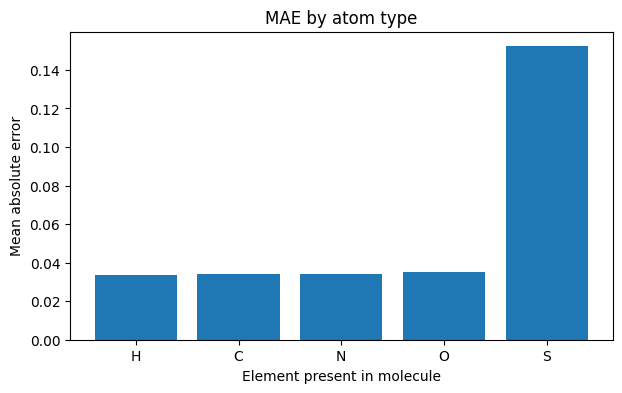

In [ ]:
atom_names = {
    1: "H",
    6: "C",
    7: "N",
    8: "O",
    9: "F",
    15: "P",
    16: "S",
    17: "Cl"
}

atom_mae = {}

for Znum in atom_names:

    mask = np.array([
        Znum in atoms
        for atoms in all_atoms
    ])

    if mask.sum() > 0:
        atom_mae[Znum] = errors[mask].mean()

labels = [atom_names[z] for z in atom_mae]
values = [atom_mae[z] for z in atom_mae]

plt.figure(figsize=(7,4))
plt.bar(labels, values)
plt.ylabel("Mean absolute error")
plt.xlabel("Element present in molecule")
plt.title("MAE by atom type")
plt.show()

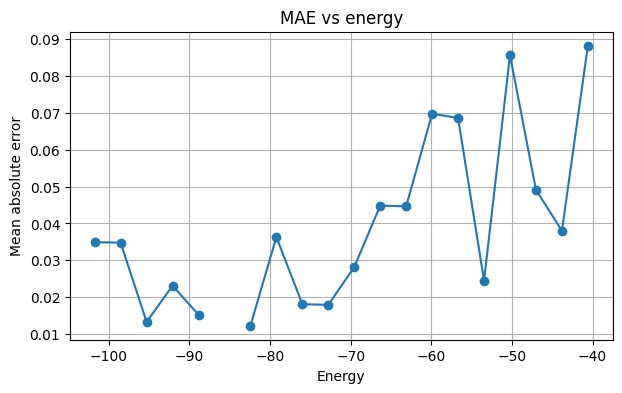

In [ ]:
idx = np.argsort(all_true)

sorted_true = all_true[idx]
sorted_err = errors[idx]

nbins = 20

bins = np.linspace(
    all_true.min(),
    all_true.max(),
    nbins + 1
)

bin_centers = 0.5 * (bins[:-1] + bins[1:])
bin_mae = []

for i in range(nbins):

    mask = (
        (all_true >= bins[i]) &
        (all_true < bins[i+1])
    )

    if mask.sum() > 0:
        bin_mae.append(errors[mask].mean())
    else:
        bin_mae.append(np.nan)

plt.figure(figsize=(7,4))
plt.plot(bin_centers, bin_mae, marker='o')
plt.xlabel("Energy")
plt.ylabel("Mean absolute error")
plt.title("MAE vs energy")
plt.grid()
plt.show()

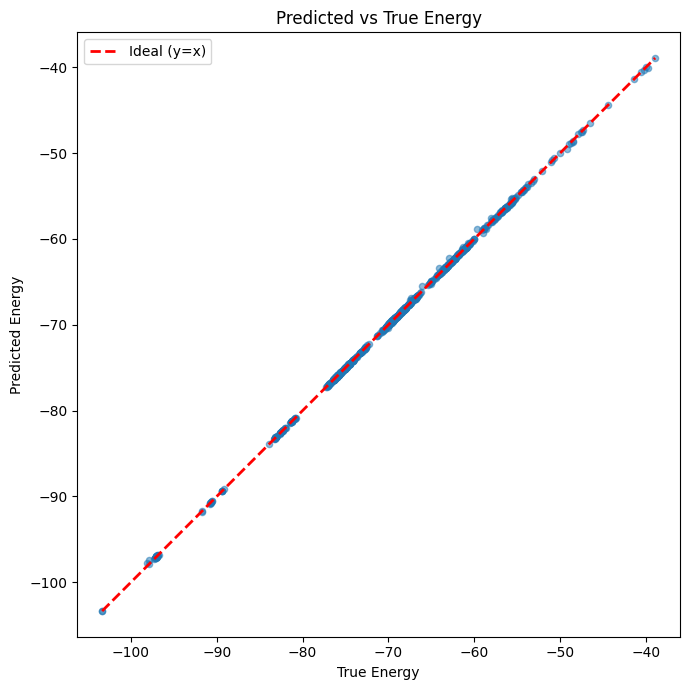

In [ ]:
plt.figure(figsize=(7,7))

# predictions
plt.scatter(
    all_true,
    all_pred,
    alpha=0.5,
    s=20
)

# ideal line y=x
emin = min(all_true.min(), all_pred.min())
emax = max(all_true.max(), all_pred.max())

plt.plot(
    [emin, emax],
    [emin, emax],
    'r--',
    linewidth=2,
    label='Ideal (y=x)'
)

plt.xlabel("True Energy")
plt.ylabel("Predicted Energy")
plt.title("Predicted vs True Energy")
plt.legend()
plt.axis('equal')
plt.tight_layout()
plt.show()

In [ ]:
class WarmupCosineDecayRestarts(tf.keras.optimizers.schedules.LearningRateSchedule):
    """Linear warmup, then cosine decay with restarts."""

    def __init__(
        self,
        initial_learning_rate: float,
        first_decay_steps: int,
        warmup_steps: int,
        t_mul: float = 2.0,
        m_mul: float = 1.0,
        alpha: float = 0.0,
    ):
        super().__init__()
        self.initial_learning_rate = initial_learning_rate
        self.first_decay_steps = first_decay_steps
        self.warmup_steps = warmup_steps

        self._cosine = tf.keras.optimizers.schedules.CosineDecayRestarts(
            initial_learning_rate=initial_learning_rate,
            first_decay_steps=first_decay_steps,
            t_mul=t_mul,
            m_mul=m_mul,
            alpha=alpha,
        )

    def __call__(self, step):
        step = tf.cast(step, tf.float32)
        warmup_steps = tf.cast(self.warmup_steps, tf.float32)

        # Linear ramp from 0 → initial_learning_rate
        warmup_lr = self.initial_learning_rate * (step / warmup_steps)

        # Cosine restarts (offset so cycle starts after warmup)
        cosine_lr = self._cosine(step - warmup_steps)

        return tf.cond(step < warmup_steps, lambda: warmup_lr, lambda: cosine_lr)

    def get_config(self):
        config = self._cosine.get_config()
        config.update({"warmup_steps": self.warmup_steps})
        return config

In [ ]:
"""import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

schedule = WarmupCosineDecayRestarts(0.005, 10000, 500, m_mul=0.9)

steps = np.arange(0, 70500)
lrs = []
for s in tqdm(steps):
    lrs.append(schedule(s).numpy())

plt.plot(steps, lrs)
plt.title("Warmup + Cosine Decay with Restarts")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.grid(True)
plt.show()"""

'import matplotlib.pyplot as plt\nimport numpy as np\nfrom tqdm import tqdm\n\nschedule = WarmupCosineDecayRestarts(0.005, 10000, 500, m_mul=0.9)\n\nsteps = np.arange(0, 70500)\nlrs = []\nfor s in tqdm(steps):\n    lrs.append(schedule(s).numpy())\n\nplt.plot(steps, lrs)\nplt.title("Warmup + Cosine Decay with Restarts")\nplt.xlabel("Step")\nplt.ylabel("Learning Rate")\nplt.grid(True)\nplt.show()'